In [1]:
import xgboost

print(xgboost.__version__)


3.4.1


In [2]:
import pandas as pd
import numpy as np

train = pd.read_csv(
    "../data/processed/failure_train.csv",
    parse_dates=["snapshot_date"]
)

validation = pd.read_csv(
    "../data/processed/failure_validation.csv",
    parse_dates=["snapshot_date"]
)

test = pd.read_csv(
    "../data/processed/failure_test.csv",
    parse_dates=["snapshot_date"]
)

print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)

Train: (72000, 14)
Validation: (12000, 14)
Test: (7000, 14)


In [3]:
feature_columns = [
    "asset_age_years",
    "condition_score",
    "criticality",
    "usage_factor",
    "weather_stress",
    "historical_failure_count",
    "historical_downtime_hours",
    "days_since_last_failure"
]

target_column = "failure_within_30_days"


In [4]:
X_train = train[feature_columns]
y_train = train[target_column]

X_validation = validation[feature_columns]
y_validation = validation[target_column]

X_test = test[feature_columns]
y_test = test[target_column]

In [5]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)

X_validation_imputed = imputer.transform(X_validation)

X_test_imputed = imputer.transform(X_test)

In [6]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

print("No failure:", negative)
print("Failure:", positive)

No failure: 71684
Failure: 316


In [7]:
scale_pos_weight = negative / positive

print(
    "scale_pos_weight:",
    scale_pos_weight
)

scale_pos_weight: 226.84810126582278


In [8]:
from xgboost import XGBClassifier

In [9]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

In [10]:
xgb_model.fit(
    X_train_imputed,
    y_train
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [11]:
y_pred = xgb_model.predict(
    X_test_imputed
)

In [12]:
y_probability = xgb_model.predict_proba(
    X_test_imputed
)[:, 1]

In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [14]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test, y_probability))

Accuracy : 0.9115714285714286
Precision: 0.010362694300518135
Recall   : 0.11538461538461539
F1 Score : 0.01901743264659271
ROC-AUC  : 0.49486847349541646


In [15]:
print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred
    )
)


Confusion Matrix:
[[6375  573]
 [  46    6]]


In [16]:
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.92      0.95      6948
           1       0.01      0.12      0.02        52

    accuracy                           0.91      7000
   macro avg       0.50      0.52      0.49      7000
weighted avg       0.99      0.91      0.95      7000



In [17]:
validation_pred = xgb_model.predict(
    X_validation_imputed
)

validation_probability = xgb_model.predict_proba(
    X_validation_imputed
)[:, 1]

In [18]:
print(
    "Validation F1:",
    f1_score(
        y_validation,
        validation_pred,
        zero_division=0
    )
)

print(
    "Validation ROC-AUC:",
    roc_auc_score(
        y_validation,
        validation_probability
    )
)

Validation F1: 0.008703220191470844
Validation ROC-AUC: 0.5924403167161036


In [19]:
train_pred = xgb_model.predict(
    X_train_imputed
)

train_probability = xgb_model.predict_proba(
    X_train_imputed
)[:, 1]

print(
    "Training F1:",
    f1_score(
        y_train,
        train_pred,
        zero_division=0
    )
)

print(
    "Test F1:",
    f1_score(
        y_test,
        y_pred,
        zero_division=0
    )
)

Training F1: 0.08342245989304813
Test F1: 0.01901743264659271


In [20]:
importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance

,feature,importance
1,condition_score,0.146781
4,weather_stress,0.138153
0,asset_age_years,0.129653
3,usage_factor,0.128017
7,days_since_last_failure,0.120128
2,criticality,0.118480
6,historical_downtime_hours,0.117587
5,historical_failure_count,0.101201


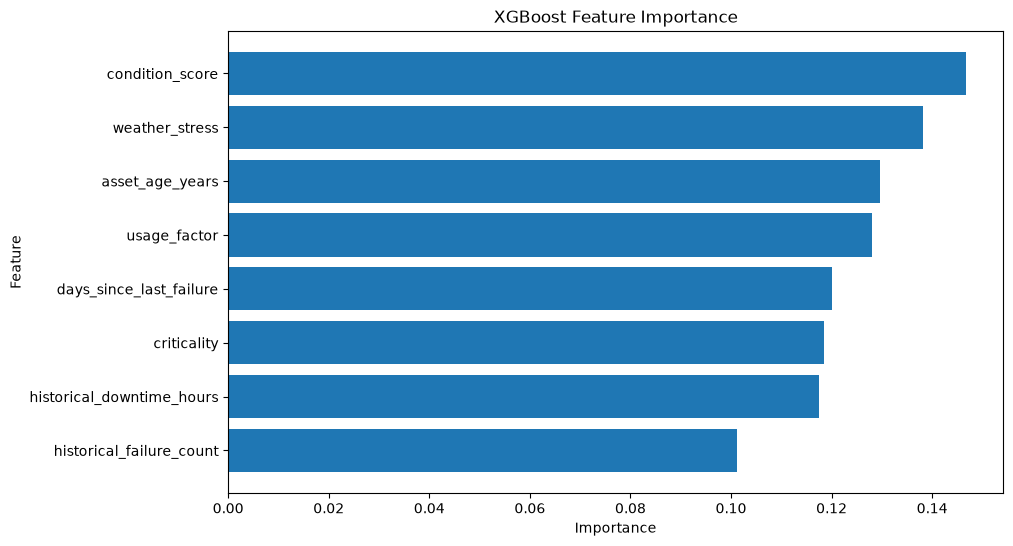

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    importance["feature"],
    importance["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

# XGBoost
results.append({
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1": f1_score(y_test, y_pred, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, y_probability)
})

model_comparison = pd.DataFrame(results)

model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,XGBoost,0.911571,0.010363,0.115385,0.019017,0.494868


In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

# XGBoost
results.append({
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1": f1_score(y_test, y_pred, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, y_probability)
})

model_comparison = pd.DataFrame(results)

model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,XGBoost,0.911571,0.010363,0.115385,0.019017,0.494868


In [24]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_predictions(file_path):
    
    data = pd.read_csv(file_path)
    
    y_true = data["failure_within_30_days"]
    y_pred = data["predicted_failure"]
    y_probability = data["failure_probability"]
    
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_true,
            y_probability
        )
    }

In [25]:
logistic_results = evaluate_predictions(
    "../data/predictions/logistic_failure_predictions.csv"
)

tree_results = evaluate_predictions(
    "../data/predictions/decision_tree_failure_predictions.csv"
)

rf_results = evaluate_predictions(
    "../data/predictions/random_forest_failure_predictions.csv"
)

xgb_results = evaluate_predictions(
    "../data/predictions/xgboost_failure_predictions.csv"
)

In [26]:
# Create XGBoost prediction table

xgb_predictions = test[
    [
        "asset_id",
        "snapshot_date",
        "section_id",
        "department",
        "asset_type",
        "condition_score",
        "criticality",
        "failure_within_30_days"
    ]
].copy()

xgb_predictions["failure_probability"] = y_probability
xgb_predictions["predicted_failure"] = y_pred

# Sort highest-risk assets first
xgb_predictions = xgb_predictions.sort_values(
    "failure_probability",
    ascending=False
)

# Save predictions
xgb_predictions.to_csv(
    "../data/predictions/xgboost_failure_predictions.csv",
    index=False
)

print("XGBoost prediction file saved successfully.")
print(xgb_predictions.head())

XGBoost prediction file saved successfully.
        asset_id snapshot_date  section_id   department       asset_type  \
1314  ASSET00188    2026-06-01  NDL-MTJ-01  ENGINEERING          TURNOUT   
1259  ASSET00180    2026-07-01  NDL-MTJ-01  ENGINEERING            TRACK   
1202  ASSET00172    2026-06-01  VAD-SRT-01     TRACTION  SECTIONING_POST   
2295  ASSET00328    2026-07-01  GWL-JHS-01     TRACTION              OHE   
1772  ASSET00254    2026-02-01  VAD-SRT-01          S&T           SIGNAL   

      condition_score  criticality  failure_within_30_days  \
1314        67.076800           10                       0   
1259        80.561398           10                       0   
1202        67.584382            8                       0   
2295        79.644448            8                       0   
1772        77.605723            5                       0   

      failure_probability  predicted_failure  
1314             0.873860                  1  
1259             0.866416       

In [27]:
import os

file_path = "../data/predictions/xgboost_failure_predictions.csv"

print("File exists:", os.path.exists(file_path))
print("File path:", os.path.abspath(file_path))

File exists: True
File path: /home/chirag/projects/railway-ai/data/predictions/xgboost_failure_predictions.csv


In [28]:
xgb_results = evaluate_predictions(
    "../data/predictions/xgboost_failure_predictions.csv"
)

In [29]:
comparison = pd.DataFrame([
    {"Model": "Logistic Regression", **logistic_results},
    {"Model": "Decision Tree", **tree_results},
    {"Model": "Random Forest", **rf_results},
    {"Model": "XGBoost", **xgb_results}
])

comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.452143,0.010861,0.807692,0.021434,0.685438
1,Decision Tree,0.438143,0.008112,0.615385,0.016012,0.569018
2,Random Forest,0.883429,0.005181,0.076923,0.009709,0.532162
3,XGBoost,0.911571,0.010363,0.115385,0.019017,0.494868


In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_predictions(file_path):
    
    data = pd.read_csv(file_path)
    
    y_true = data["failure_within_30_days"]
    y_pred = data["predicted_failure"]
    y_probability = data["failure_probability"]
    
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_probability)
    }

In [31]:
logistic_results = evaluate_predictions(
    "../data/predictions/logistic_failure_predictions.csv"
)

tree_results = evaluate_predictions(
    "../data/predictions/decision_tree_failure_predictions.csv"
)

rf_results = evaluate_predictions(
    "../data/predictions/random_forest_failure_predictions.csv"
)

xgb_results = evaluate_predictions(
    "../data/predictions/xgboost_failure_predictions.csv"
)

In [32]:
comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        **logistic_results
    },
    {
        "Model": "Decision Tree",
        **tree_results
    },
    {
        "Model": "Random Forest",
        **rf_results
    },
    {
        "Model": "XGBoost",
        **xgb_results
    }
])

comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.452143,0.010861,0.807692,0.021434,0.685438
1,Decision Tree,0.438143,0.008112,0.615385,0.016012,0.569018
2,Random Forest,0.883429,0.005181,0.076923,0.009709,0.532162
3,XGBoost,0.911571,0.010363,0.115385,0.019017,0.494868


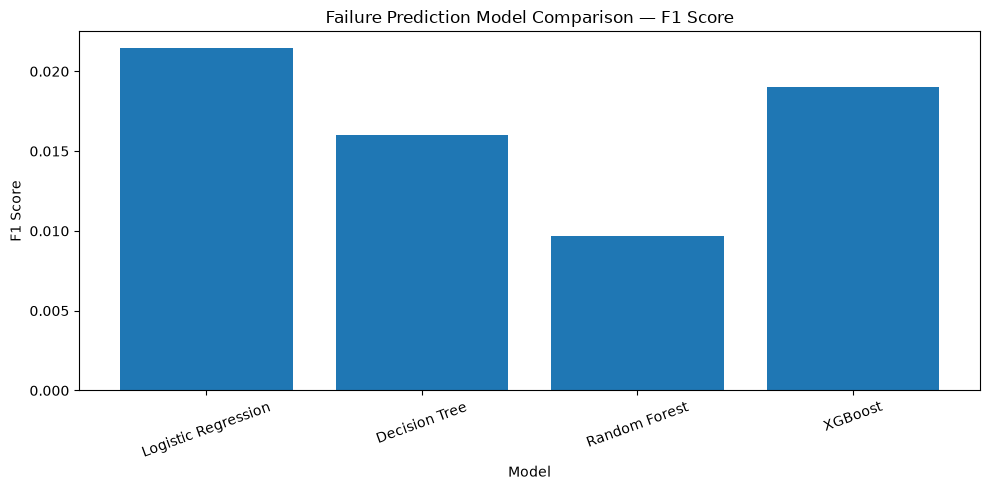

In [33]:
plt.figure(figsize=(10, 5))

plt.bar(
    comparison["Model"],
    comparison["F1"]
)

plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.title("Failure Prediction Model Comparison — F1 Score")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

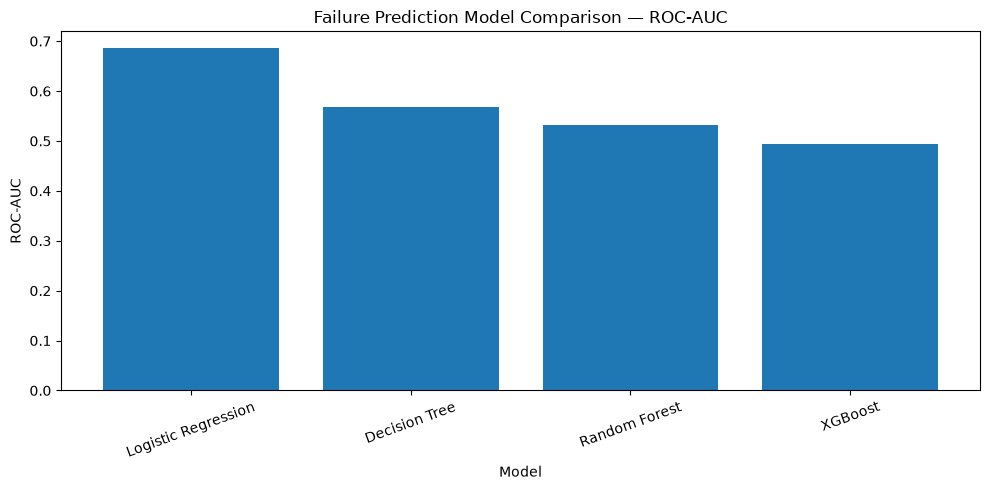

In [34]:
plt.figure(figsize=(10, 5))

plt.bar(
    comparison["Model"],
    comparison["ROC_AUC"]
)

plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.title("Failure Prediction Model Comparison — ROC-AUC")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()